In [1]:
!pip install mysql-connector-python

In [2]:
import mysql.connector as conn

In [3]:
mydb = conn.connect(host='127.0.0.1' , user = 'root' , passwd = 'Ravish@2004')

In [4]:
mydb

In [5]:
cursor=mydb.cursor()

In [6]:
cursor.execute("show databases")

In [7]:
cursor.fetchall()

[('ecommerce',),
 ('eda',),
 ('epl',),
 ('flipkart',),
 ('geeksfogeeks',),
 ('information_schema',),
 ('insurance',),
 ('mysql',),
 ('online_sales',),
 ('performance_schema',),
 ('pysql',),
 ('pysql1',),
 ('sqlsubquery',),
 ('student',),
 ('studentperformance',),
 ('swiggy',),
 ('xyz',),
 ('zomato',)]

In [9]:
cursor.execute("create database sales_db")

In [10]:
cursor.execute("show databases")

In [11]:
cursor.fetchall()

[('ecommerce',),
 ('eda',),
 ('epl',),
 ('flipkart',),
 ('geeksfogeeks',),
 ('information_schema',),
 ('insurance',),
 ('mysql',),
 ('online_sales',),
 ('performance_schema',),
 ('pysql',),
 ('pysql1',),
 ('sales_db',),
 ('sqlsubquery',),
 ('student',),
 ('studentperformance',),
 ('swiggy',),
 ('xyz',),
 ('zomato',)]

In [14]:
cursor.execute('''
               CREATE TABLE sales_db.sales (
                    id INT AUTO_INCREMENT PRIMARY KEY,
                    product VARCHAR(100),
                    quantity INT,
                    price DECIMAL(10,2)
                    );
               ''')

In [15]:
cursor.execute('use sales_db')

In [16]:
cursor.execute('show tables')

In [17]:
cursor.fetchall()

[('sales',)]

In [18]:
mydb.commit()

In [19]:
data = [
    ("Apples", 10, 2.5),
    ("Bananas", 5, 1.0),
    ("Oranges", 8, 1.8),
    ("Apples", 6, 2.5),
    ("Bananas", 7, 1.0),
    ("Grapes", 12, 3.0),
    ("Oranges", 5, 1.8),
]

In [20]:
cursor.executemany("insert into sales(product,quantity,price) values(%s,%s,%s)",data)

In [21]:
mydb.commit()

In [22]:
cursor.execute("select * from sales")

In [23]:
cursor.fetchall()

[(1, 'Apples', 10, Decimal('2.50')),
 (2, 'Bananas', 5, Decimal('1.00')),
 (3, 'Oranges', 8, Decimal('1.80')),
 (4, 'Apples', 6, Decimal('2.50')),
 (5, 'Bananas', 7, Decimal('1.00')),
 (6, 'Grapes', 12, Decimal('3.00')),
 (7, 'Oranges', 5, Decimal('1.80'))]

In [35]:
##Reading the query 
query = """
            select product , sum(quantity),sum(quantity * price) as revenue from sales group by product;
        """
            

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
df = pd.read_sql(query,mydb)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4620\2464276641.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,mydb)


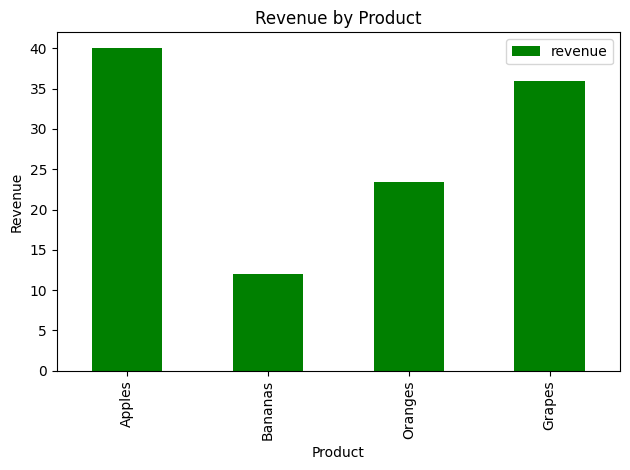

In [39]:
df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product', color='green')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

In [41]:
import os

In [42]:
os.getcwd()

'C:\\Users\\ASUS\\SQLConnector'